In [6]:
import duckdb
import pandas as pd
import numpy as np


con = duckdb.connect(
r"C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\gold\realestate_gold.duckdb"
)


ml_df = con.execute("""
SELECT *
FROM ml_tax_delinquency_2025
""").df()

ml_df = ml_df[
   (ml_df["building_area"] > 500) &
  (ml_df["total_market_value"] > 50000)
]

print(ml_df.shape)
ml_df.head()

(867574, 24)


,acct,tax_year,site_addr_1,situs_full,addr_key,addr_key_no_unit,owner_entity_flag,absentee_owner_flag,neighborhood_code,year_built,...,acreage,total_market_value,value_per_sqft,protested_flag,cnt_311_total_all,cnt_311_property_maintenance,cnt_311_vehicle_issues,cnt_311_building_standards,cnt_311_nuisance,target_tax_delinquent
0,0631170010002,2025,3007 WICHITA ST,3007 WICHITA ST HOUSTON 77004,3007 WICHITA ST,3007 WICHITA ST,0,1,8401.01,1911,...,0.1205,522171,189.742369,0,2,0.0,0.0,0.0,0.0,0
1,0631170010003,2025,3009 WICHITA ST,3009 WICHITA ST HOUSTON 77004,3009 WICHITA ST,3009 WICHITA ST,0,0,8401.01,1954,...,0.1205,277835,148.336893,0,2,1.0,0.0,0.0,0.0,0
2,0631170010004,2025,3015 WICHITA ST,3015 WICHITA ST HOUSTON 77004,3015 WICHITA ST,3015 WICHITA ST,0,0,8401.01,1949,...,0.1205,255561,150.065179,0,1,0.0,0.0,0.0,0.0,0
3,0631170010005,2025,3019 WICHITA ST,3019 WICHITA ST HOUSTON 77004,3019 WICHITA ST,3019 WICHITA ST,1,1,8401.01,1949,...,0.1205,243899,145.524463,0,3,0.0,0.0,2.0,0.0,0
4,0631170010010,2025,3115 WICHITA ST,3115 WICHITA ST HOUSTON 77004,3115 WICHITA ST,3115 WICHITA ST,0,1,8401.01,1940,...,0.1205,245940,102.347066,0,1,0.0,0.0,0.0,0.0,0


In [7]:
missing = ml_df.isna().sum().sort_values(ascending=False)

missing_pct = (missing / len(ml_df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print(missing_df.head(24))

                              missing_count  missing_pct
years_owned                              25     0.002882
year_built                                1     0.000115
property_age                              1     0.000115
acct                                      0     0.000000
addr_key                                  0     0.000000
tax_year                                  0     0.000000
site_addr_1                               0     0.000000
situs_full                                0     0.000000
absentee_owner_flag                       0     0.000000
owner_entity_flag                         0     0.000000
addr_key_no_unit                          0     0.000000
neighborhood_code                         0     0.000000
building_area                             0     0.000000
lot_size                                  0     0.000000
acreage                                   0     0.000000
total_market_value                        0     0.000000
value_per_sqft                 

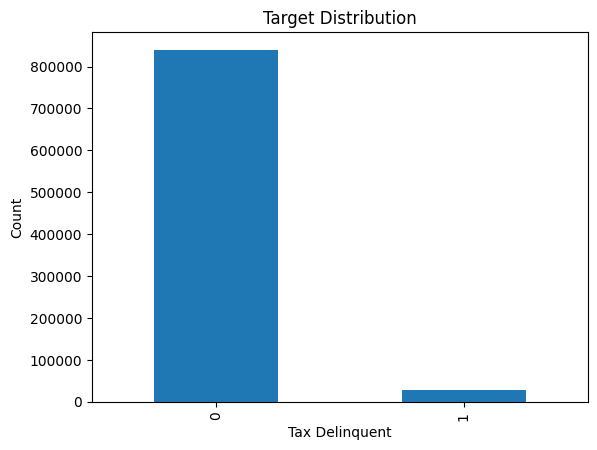

In [8]:
import matplotlib.pyplot as plt

ml_df["target_tax_delinquent"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Tax Delinquent")
plt.ylabel("Count")
plt.show()

In [9]:
ml_df["target_tax_delinquent"].value_counts(normalize=True)

target_tax_delinquent
0    0.968026
1    0.031974
Name: proportion, dtype: float64

In [10]:
numeric_cols = ml_df.select_dtypes(include=["int64","float64"]).columns

corr = ml_df[numeric_cols].corr()

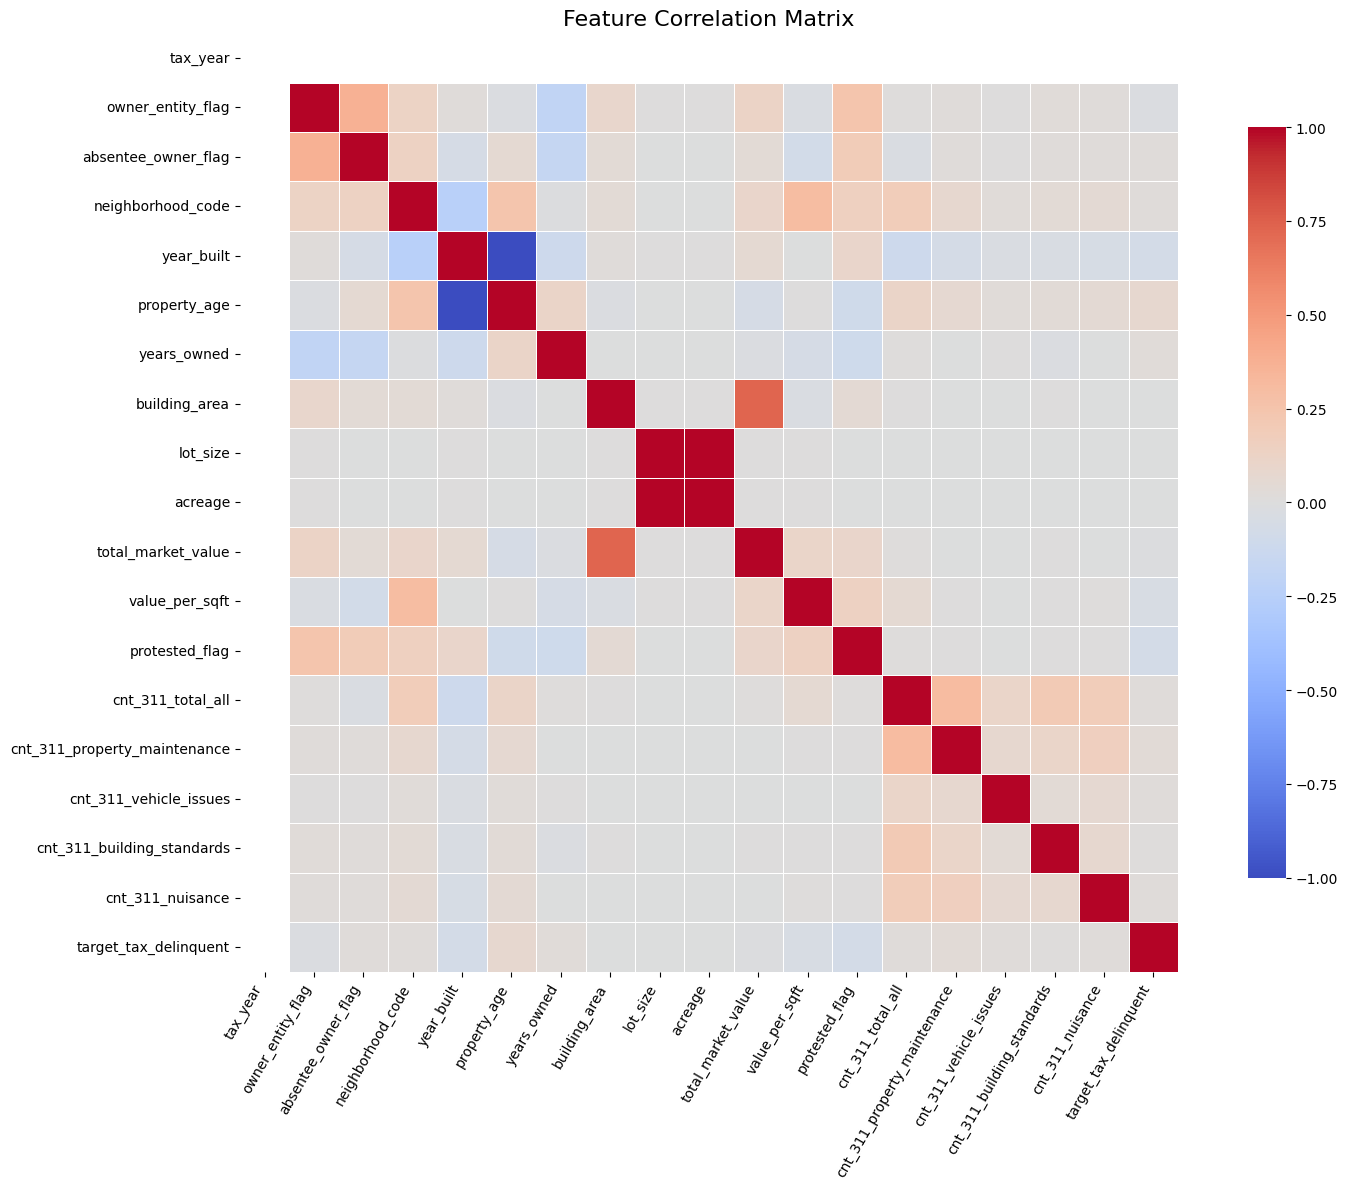

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ml_df.select_dtypes(include=["int64","float64"]).columns

corr = ml_df[numeric_cols].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)

plt.title("Feature Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

In [12]:
target_corr = corr["target_tax_delinquent"].sort_values(ascending=False)

print(target_corr)

target_tax_delinquent           1.000000
property_age                    0.077503
cnt_311_property_maintenance    0.034813
years_owned                     0.025556
neighborhood_code               0.023276
cnt_311_nuisance                0.022389
absentee_owner_flag             0.019460
cnt_311_vehicle_issues          0.016509
cnt_311_total_all               0.016249
cnt_311_building_standards      0.011447
acreage                        -0.000233
lot_size                       -0.000233
building_area                  -0.003491
total_market_value             -0.012487
owner_entity_flag              -0.019980
value_per_sqft                 -0.044948
protested_flag                 -0.077302
year_built                     -0.077503
tax_year                             NaN
Name: target_tax_delinquent, dtype: float64


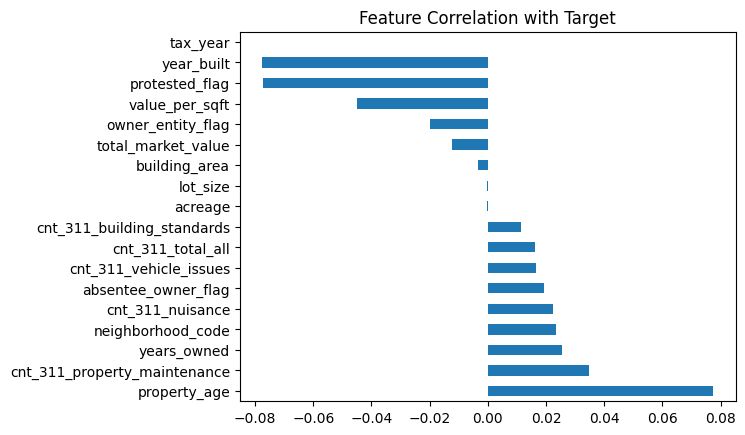

In [13]:
target_corr.drop("target_tax_delinquent").plot(kind="barh")

plt.title("Feature Correlation with Target")
plt.show()

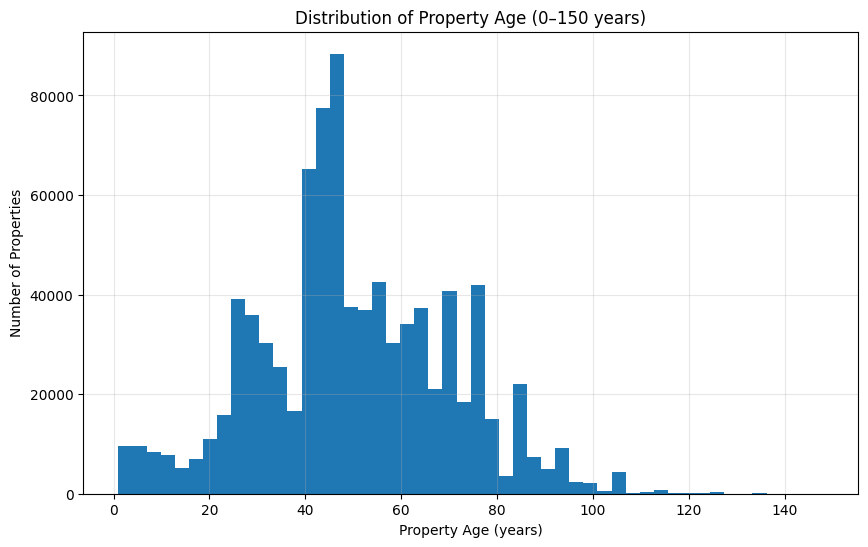

In [14]:
# keep realistic ages
age = ml_df["property_age"]
age = age[(age > 0) & (age < 150)]

plt.figure(figsize=(10,6))

plt.hist(age, bins=50)

plt.title("Distribution of Property Age (0–150 years)")
plt.xlabel("Property Age (years)")
plt.ylabel("Number of Properties")

plt.grid(alpha=0.3)

plt.show()

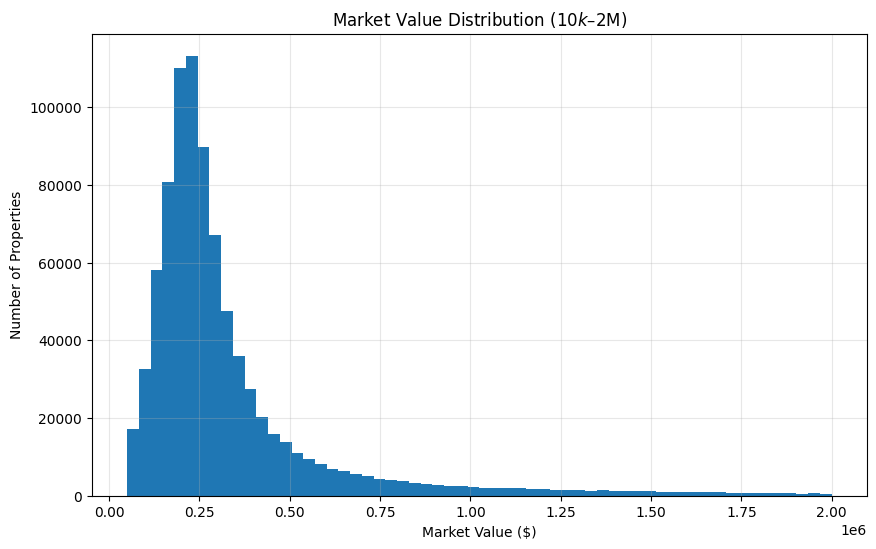

In [15]:
values = ml_df["total_market_value"]
values = values[(values > 10000) & (values < 2000000)]

plt.figure(figsize=(10,6))

plt.hist(values, bins=60)

plt.title("Market Value Distribution ($10k–$2M)")
plt.xlabel("Market Value ($)")
plt.ylabel("Number of Properties")

plt.grid(alpha=0.3)

plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_2532\3589833467.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_rates = ml_df.groupby("value_bucket")["target_tax_delinquent"].mean()


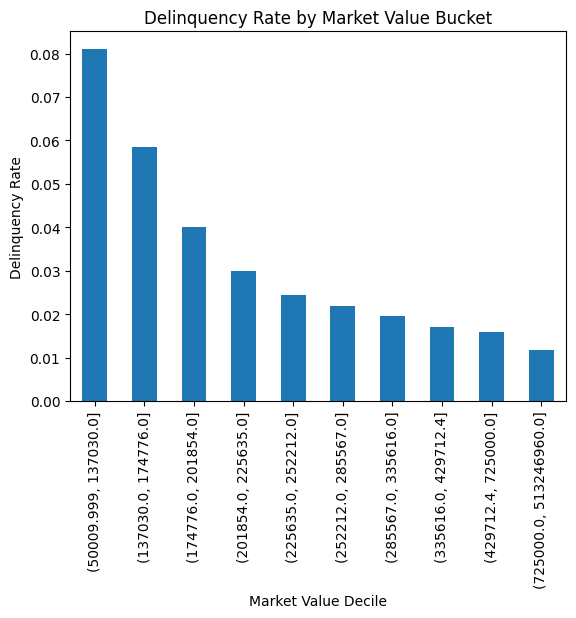

In [16]:
ml_df["value_bucket"] = pd.qcut(
    ml_df["total_market_value"],
    10,
    duplicates="drop"
)

bucket_rates = ml_df.groupby("value_bucket")["target_tax_delinquent"].mean()

bucket_rates.plot(kind="bar")

plt.title("Delinquency Rate by Market Value Bucket")
plt.ylabel("Delinquency Rate")
plt.xlabel("Market Value Decile")

plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_2532\1543310978.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_df.groupby("price_bucket")


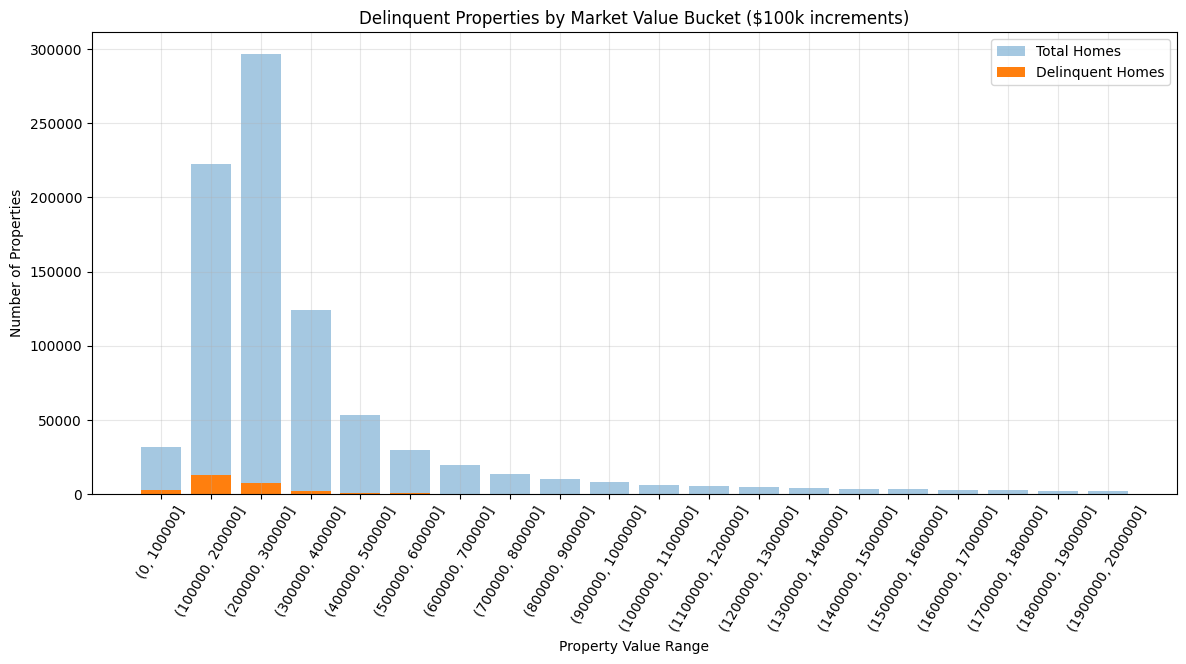

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create fixed bins every 100k up to 2M
bins = np.arange(0, 2000000 + 100000, 100000)

ml_df["price_bucket"] = pd.cut(
    ml_df["total_market_value"],
    bins=bins
)

# summarize
bucket_summary = (
    ml_df.groupby("price_bucket")
    .agg(
        total_properties=("acct","count"),
        delinquent=("target_tax_delinquent","sum")
    )
    .reset_index()
)

# plot
plt.figure(figsize=(14,6))

plt.bar(
    bucket_summary["price_bucket"].astype(str),
    bucket_summary["total_properties"],
    alpha=0.4,
    label="Total Homes"
)

plt.bar(
    bucket_summary["price_bucket"].astype(str),
    bucket_summary["delinquent"],
    label="Delinquent Homes"
)

plt.xticks(rotation=60)

plt.xlabel("Property Value Range")
plt.ylabel("Number of Properties")

plt.title("Delinquent Properties by Market Value Bucket ($100k increments)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:
neighborhood_stats = (
    ml_df.groupby("neighborhood_code")
    .agg(
        n_properties=("acct", "count"),
        n_delinquent=("target_tax_delinquent", "sum"),
        delinquency_rate=("target_tax_delinquent", "mean")
    )
    .sort_values(["delinquency_rate", "n_properties"], ascending=[False, False])
)

print(neighborhood_stats.head(30))

                   n_properties  n_delinquent  delinquency_rate
neighborhood_code                                              
5637.01                      16            16          1.000000
946.05                        1             1          1.000000
9809.02                       1             1          1.000000
9824.08                       1             1          1.000000
9990.03                       1             1          1.000000
2699.07                      18            15          0.833333
2178.01                       5             4          0.800000
5672.05                       5             4          0.800000
9358.07                       2             1          0.500000
9700.05                       2             1          0.500000
9996.02                       2             1          0.500000
2499.08                      11             5          0.454545
2426.05                       7             3          0.428571
2500.05                      11         

<Axes: >

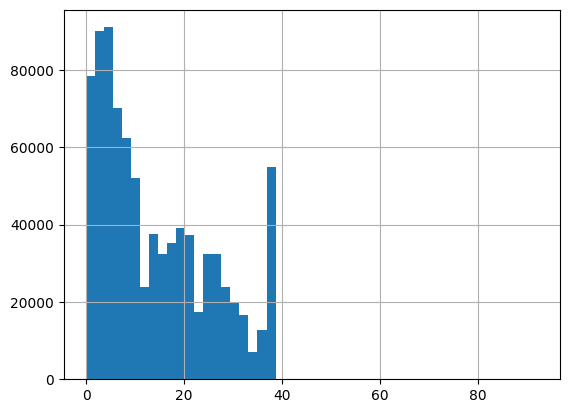

In [19]:
ml_df["years_owned"].hist(bins=50)

In [20]:
ml_df.groupby("target_tax_delinquent")["years_owned"].median()

target_tax_delinquent
0    11.0
1    13.0
Name: years_owned, dtype: Float64

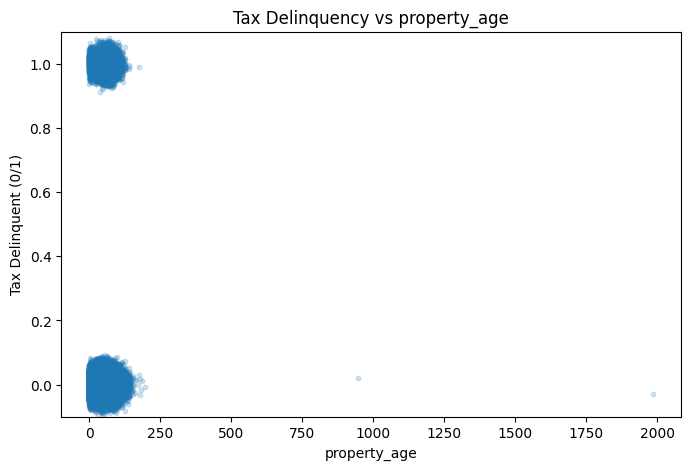

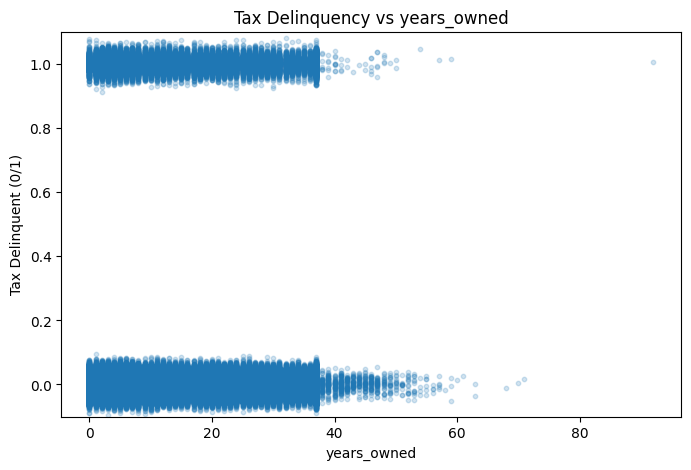

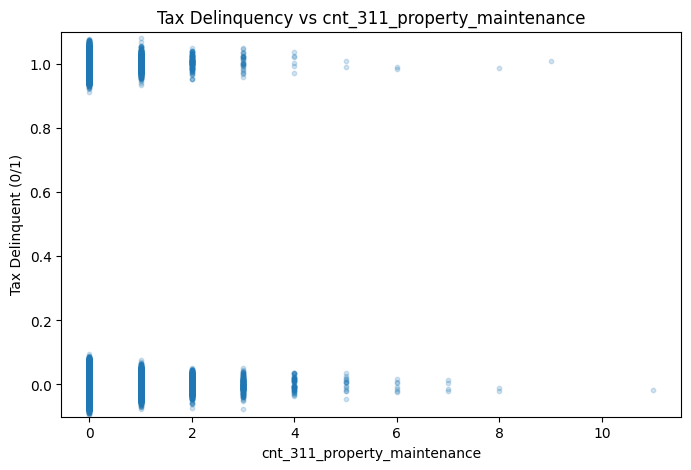

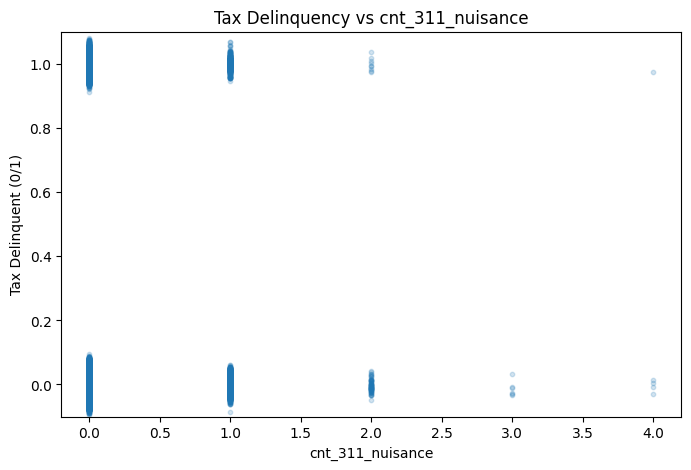

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# small jitter so points don't overlap
y_jitter = ml_df["target_tax_delinquent"] + np.random.normal(0, 0.02, len(ml_df))

features = [
    "property_age",
    "years_owned",
    "cnt_311_property_maintenance",
    "cnt_311_nuisance"
]

for feature in features:

    plt.figure(figsize=(8,5))

    plt.scatter(
        ml_df[feature],
        y_jitter,
        alpha=0.2,
        s=10
    )

    plt.xlabel(feature)
    plt.ylabel("Tax Delinquent (0/1)")
    plt.title(f"Tax Delinquency vs {feature}")

    plt.ylim(-0.1,1.1)

    plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_2532\3918122681.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = ml_df.groupby("age_bin")["target_tax_delinquent"].mean()


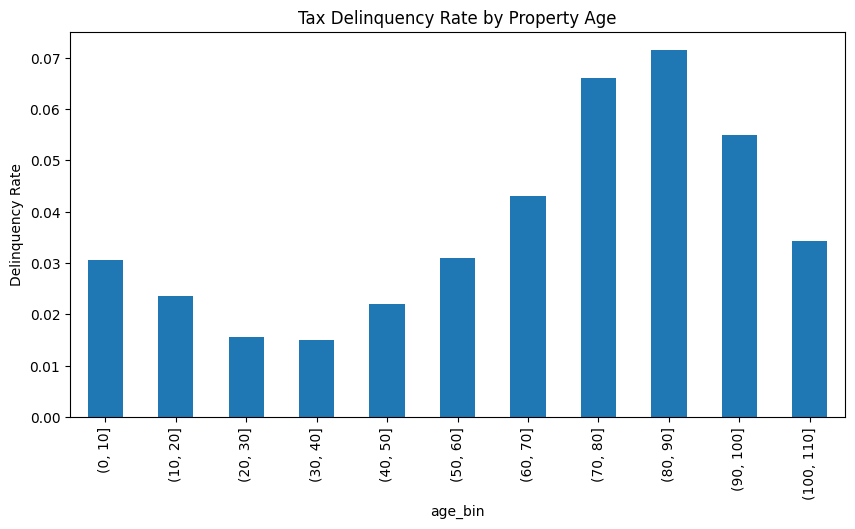

In [22]:
bins = np.arange(0,120,10)

ml_df["age_bin"] = pd.cut(ml_df["property_age"], bins)

age_rate = ml_df.groupby("age_bin")["target_tax_delinquent"].mean()

age_rate.plot(kind="bar", figsize=(10,5))

plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate by Property Age")
plt.show()

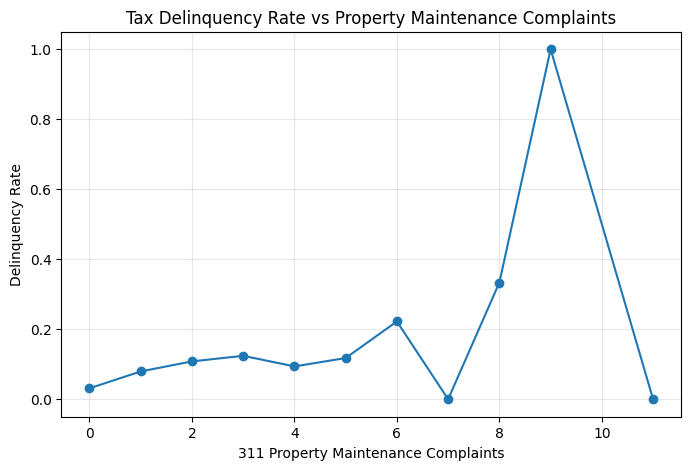

In [23]:
rate = (
    ml_df.groupby("cnt_311_property_maintenance")["target_tax_delinquent"]
    .mean()
)

count = (
    ml_df.groupby("cnt_311_property_maintenance")["acct"]
    .count()
)
subset = ml_df[ml_df["cnt_311_property_maintenance"] <= 5]
plt.figure(figsize=(8,5))

plt.plot(rate.index, rate.values, marker="o")

plt.xlabel("311 Property Maintenance Complaints")
plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate vs Property Maintenance Complaints")

plt.grid(alpha=0.3)
plt.show()

In [24]:
print(pd.concat([rate, count], axis=1).rename(
    columns={0:"delinquency_rate", "acct":"n_properties"}
))

                              target_tax_delinquent  n_properties
cnt_311_property_maintenance                                     
0.0                                        0.031241        855359
1.0                                        0.079319         10691
2.0                                        0.108085          1175
3.0                                        0.124000           250
4.0                                        0.093750            64
5.0                                        0.117647            17
6.0                                        0.222222             9
7.0                                        0.000000             4
8.0                                        0.333333             3
9.0                                        1.000000             1
11.0                                       0.000000             1


C:\Users\howar\AppData\Local\Temp\ipykernel_2532\2591905273.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_df.groupby("ownership_bin")["target_tax_delinquent"]


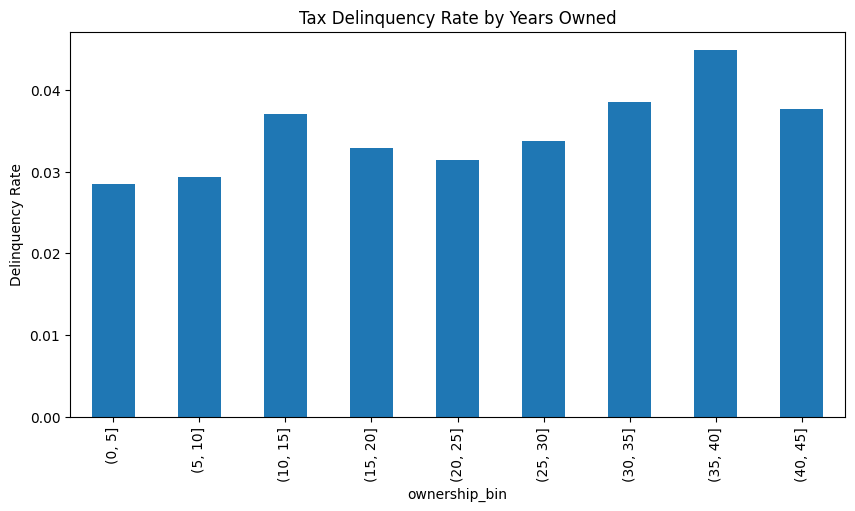

In [25]:
bins = np.arange(0,50,5)

ml_df["ownership_bin"] = pd.cut(ml_df["years_owned"], bins)

ownership_rate = (
    ml_df.groupby("ownership_bin")["target_tax_delinquent"]
    .mean()
)

ownership_rate.plot(kind="bar", figsize=(10,5))

plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate by Years Owned")
plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_2532\2271263403.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = temp.pivot_table(


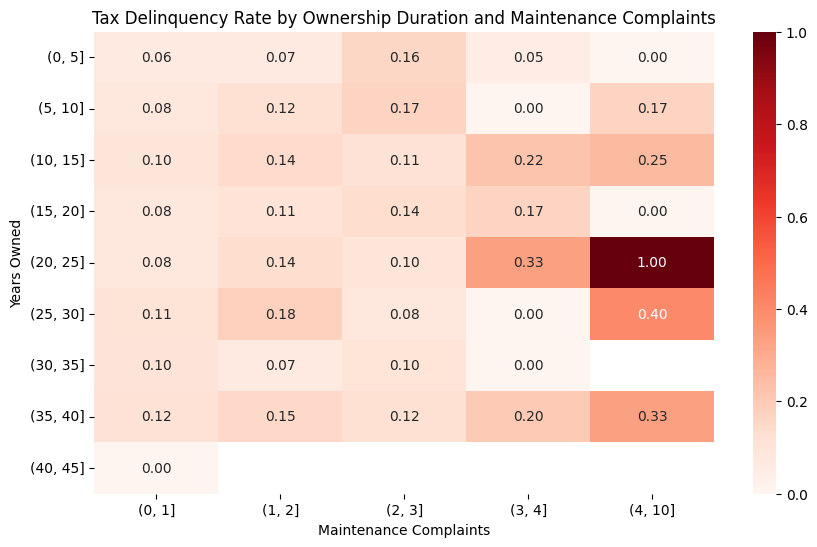

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# temporary bins (no new ML feature created)
ownership_bins = np.arange(0,50,5)
complaint_bins = [0,1,2,3,4,10]

temp = ml_df.copy()

temp["ownership_bin"] = pd.cut(temp["years_owned"], ownership_bins)
temp["maintenance_bin"] = pd.cut(temp["cnt_311_property_maintenance"], complaint_bins)

heat = temp.pivot_table(
    values="target_tax_delinquent",
    index="ownership_bin",
    columns="maintenance_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    heat,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Tax Delinquency Rate by Ownership Duration and Maintenance Complaints")
plt.xlabel("Maintenance Complaints")
plt.ylabel("Years Owned")

plt.show()

X shape: (867574, 17)
Number of features: 17

Top missingness rates:
years_owned                     0.0
year_built                      0.0
property_age                    0.0
owner_entity_flag               0.0
neighborhood_code               0.0
absentee_owner_flag             0.0
building_area                   0.0
lot_size                        0.0
acreage                         0.0
total_market_value              0.0
value_per_sqft                  0.0
protested_flag                  0.0
cnt_311_total_all               0.0
cnt_311_property_maintenance    0.0
cnt_311_vehicle_issues          0.0
cnt_311_building_standards      0.0
cnt_311_nuisance                0.0
dtype: float64

Sample shape for tuning: (100000, 17)
Fitting 5 folds for each of 17 candidates, totalling 85 fits

Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 25, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced_subsample'}

Best CV ROC AUC:
0.7529

Classificat

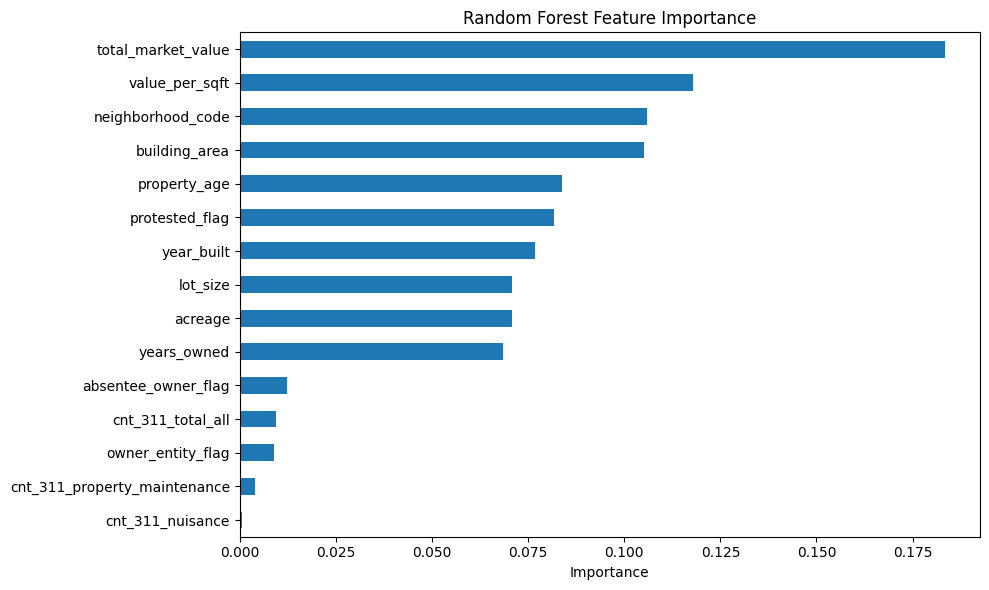

In [27]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# columns we do NOT want in the model
drop_cols = [
    "acct",
    "site_addr_1",
    "situs_full",
    "addr_key",
    "addr_key_no_unit",
    "tax_year",
    "target_tax_delinquent",
    "age_bin",
    "ownership_bin",
    "price_bucket",
    "value_bucket",
    "price_bucket_label",
]

# keep only columns that actually exist
drop_cols = [c for c in drop_cols if c in ml_df.columns]

# build X and y
X = ml_df.drop(columns=drop_cols, errors="ignore").copy()
y = ml_df["target_tax_delinquent"].copy()

# keep numeric + bool only
X = X.select_dtypes(include=["number", "bool"]).copy()

# convert bools to int
for c in X.select_dtypes(include=["bool"]).columns:
    X[c] = X[c].astype(int)

# force numeric and fill missing
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print("X shape:", X.shape)
print("Number of features:", X.shape[1])

# optional: check missingness before fill
missing_pct = ml_df[X.columns].isnull().mean().sort_values(ascending=False)
print("\nTop missingness rates:")
print((missing_pct.head(20) * 100).round(2))

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# sample training data for faster tuning
sample_size = min(100000, len(X_train))
X_sample = X_train.sample(sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

print("\nSample shape for tuning:", X_sample.shape)

# hyperparameter search space
param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10, 25],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

# base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# faster search
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=17,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# tune on sample, not full training set
search.fit(X_sample, y_sample)

best_model = search.best_estimator_

print("\nBest parameters:")
print(search.best_params_)

print("\nBest CV ROC AUC:")
print(round(search.best_score_, 4))

# fit best model on full training data
best_model.fit(X_train, y_train)

# predictions
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, preds))

print("Test ROC AUC:", round(roc_auc_score(y_test, probs), 4))
print("Test F1:", round(f1_score(y_test, preds), 4))
print("Test Precision:", round(precision_score(y_test, preds), 4))
print("Test Recall:", round(recall_score(y_test, preds), 4))

# feature importance
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 20 features:")
print(importance.head(20))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

total_market_value              0.183366
value_per_sqft                  0.117791
neighborhood_code               0.105914
building_area                   0.105046
property_age                    0.083829
protested_flag                  0.081610
year_built                      0.076835
lot_size                        0.070812
acreage                         0.070804
years_owned                     0.068519
absentee_owner_flag             0.012378
cnt_311_total_all               0.009433
owner_entity_flag               0.008921
cnt_311_property_maintenance    0.003914
cnt_311_nuisance                0.000444
cnt_311_building_standards      0.000313
cnt_311_vehicle_issues          0.000071
dtype: float64


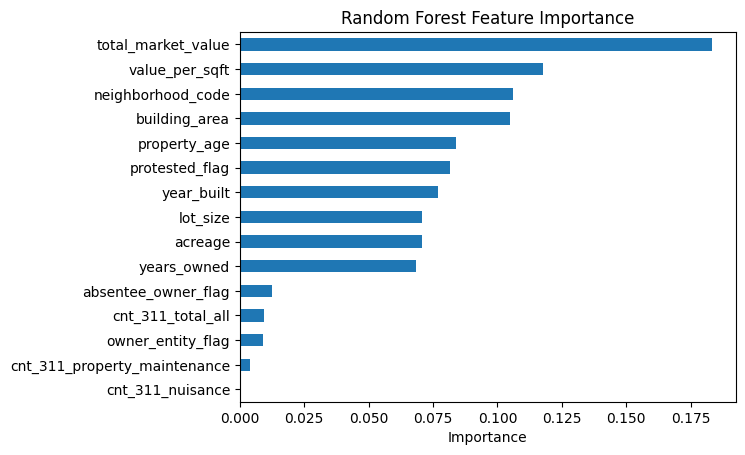

In [29]:
import matplotlib.pyplot as plt

importance.head(15).plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [30]:
import pandas as pd
import numpy as np

# build dataframe of predictions
lift_df = pd.DataFrame({
    "prob": probs,
    "actual": y_test
})

# create deciles (10 buckets)
lift_df["decile"] = pd.qcut(lift_df["prob"], 10, labels=False, duplicates="drop")

# flip order so 10 = highest risk
lift_df["decile"] = 9 - lift_df["decile"]

# calculate stats per decile
decile_table = lift_df.groupby("decile").agg(
    n_properties=("actual", "count"),
    n_delinquent=("actual", "sum"),
    delinquency_rate=("actual", "mean")
).reset_index()

# calculate lift
baseline_rate = lift_df["actual"].mean()
decile_table["lift"] = decile_table["delinquency_rate"] / baseline_rate

print(decile_table)

   decile  n_properties  n_delinquent  delinquency_rate      lift
0       0         17352          1981          0.114166  3.570553
1       1         17351          1063          0.061264  1.916061
2       2         17352           711          0.040975  1.281506
3       3         17351           491          0.028298  0.885029
4       4         17351           394          0.022708  0.710186
5       5         17352           293          0.016886  0.528103
6       6         17351           236          0.013602  0.425391
7       7         17352           173          0.009970  0.311815
8       8         17351           122          0.007031  0.219905
9       9         17352            84          0.004841  0.151402


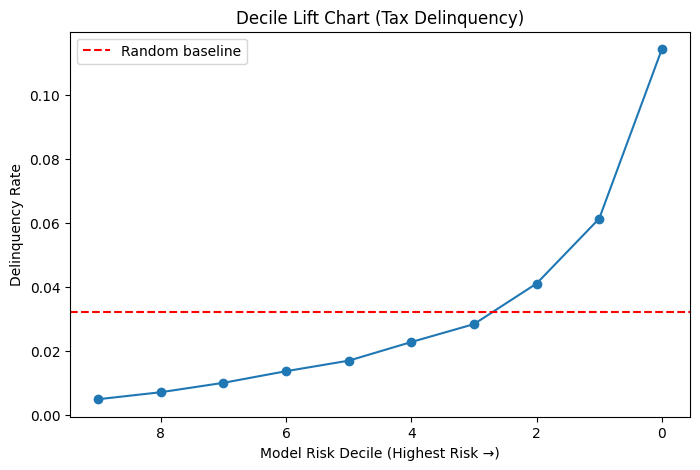

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(decile_table["decile"], decile_table["delinquency_rate"], marker="o")

plt.axhline(
    y=baseline_rate,
    color="red",
    linestyle="--",
    label="Random baseline"
)

plt.gca().invert_xaxis()

plt.title("Decile Lift Chart (Tax Delinquency)")
plt.xlabel("Model Risk Decile (Highest Risk →)")
plt.ylabel("Delinquency Rate")

plt.legend()
plt.show()

In [32]:
#Calibrate and score test set
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_model, method="sigmoid", cv=3)
calibrated_model.fit(X_train, y_train)

test_probs = calibrated_model.predict_proba(X_test)[:, 1]

In [33]:
#Score the full dataset separately

ml_df["delinquency_probability"] = best_model.predict_proba(X)[:, 1]

In [34]:
#Add risk buckets with np.select instead of apply. That is much faster than applying a Python function row by row.

conditions = [
    ml_df["delinquency_probability"] >= 0.6,
    ml_df["delinquency_probability"] >= 0.3
]

choices = ["HIGH", "MEDIUM"]

ml_df["risk_level"] = np.select(conditions, choices, default="LOW")

In [41]:
import numpy as np
import pandas as pd

# Probabilities
X_shap = X.copy()
ml_df["Probability"] = best_model.predict_proba(X_shap)[:, 1]

# Safe rule conditions
years_owned_cond = ml_df["years_owned"].fillna(0) > 15
vpsf_cond = ml_df["value_per_sqft"].fillna(np.inf) < 100
absentee_cond = ml_df["absentee_owner_flag"].fillna(0) == 1

# Rule-based reasons
reason_df = pd.DataFrame({
    "r1": np.where(years_owned_cond, "Long ownership", ""),
    "r2": np.where(vpsf_cond, "Low value per sqft", ""),
    "r3": np.where(absentee_cond, "Absentee owner", "")
}, index=ml_df.index)

ml_df["Reason"] = reason_df.apply(
    lambda row: "; ".join([x for x in row if x != ""]),
    axis=1
)
ml_df["Reason"] = ml_df["Reason"].replace("", "No major rule-based reason flagged")

# Address
ml_df["Address"] = ml_df["situs_full"].fillna("").astype(str).str.strip()
ml_df.loc[ml_df["Address"] == "", "Address"] = (
    ml_df.loc[ml_df["Address"] == "", "site_addr_1"]
    .fillna("")
    .astype(str)
    .str.strip()
)
ml_df.loc[ml_df["Address"] == "", "Address"] = (
    "Acct: " + ml_df.loc[ml_df["Address"] == "", "acct"].astype(str)
)

# Lead tier
ml_df["Lead Tier"] = np.select(
    [
        ml_df["Probability"] >= 0.80,
        ml_df["Probability"] >= 0.60,
        ml_df["Probability"] >= 0.40
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Very Low"
)

# Final output
lead_output = ml_df[["Address", "Probability", "Lead Tier", "Reason"]].copy()
lead_output = lead_output.sort_values("Probability", ascending=False)
lead_output["Probability"] = (lead_output["Probability"] * 100).round(1).astype(str) + "%"

print(lead_output.head(20))

                                 Address Probability Lead Tier  \
1041944      2812 GREGG ST HOUSTON 77026       90.7%      High   
1041455    3206 FLORIDA ST HOUSTON 77026       90.4%      High   
638162       2820 GREGG ST HOUSTON 77026       90.1%      High   
638159       2810 GREGG ST HOUSTON 77026       90.1%      High   
638161       2818 GREGG ST HOUSTON 77026       90.1%      High   
1046439   2626 BERTRAND ST HOUSTON 77093       90.1%      High   
1046436   2510 BERTRAND ST HOUSTON 77093       90.1%      High   
576312       7344 AVENUE K HOUSTON 77011       89.8%      High   
1010184      5418 WILEY RD HOUSTON 77016       89.6%      High   
1041945      2816 GREGG ST HOUSTON 77026       89.6%      High   
804355       4222 PLAAG ST HOUSTON 77016       89.5%      High   
1046435   2430 BERTRAND ST HOUSTON 77093       89.4%      High   
1046442   2910 BERTRAND ST HOUSTON 77093       89.4%      High   
765624   4922 CREEKMONT DR HOUSTON 77091       89.3%      High   
638160    

In [42]:
lead_output = ml_df[["acct", "Address", "Probability", "Lead Tier", "Reason"]].copy()

output_path = r"C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\Tax Delinquent Predictions\motivated_seller_leads.csv"

lead_output.to_csv(output_path, index=False)

print(f"File saved to: {output_path}")

File saved to: C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\Tax Delinquent Predictions\motivated_seller_leads.csv
